In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from IPython.display import clear_output
from matplotlib.widgets import Slider
from sktime.performance_metrics.forecasting import MeanSquaredError as MSEsktime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error as mse
from matplotlib.widgets import Slider
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import random

import os

Below we can specify which `state` were going to analize. If we can to used the saved models, set `load` to `True`.

In [10]:
state = 'SC'
load = True
target = 'customers_out_max' #could also be customers_out

features = ['event_count Flood','event_count Storm', 'event_count Hurricane', 'event_count Heat', 
            'event_count Fire', 'event_count Wind', 'event_count Ocean', 'event_count Other', 
            't2m', 'sf', 'tp', 't2m_mean', 't2m_max', 'sf_mean', 'sf_max', 'tp_mean',
            'tp_max', 'wind_speed', 'neighbor_max_wind_speed','customers_out_state', 'customers_out','customers_out_max']

""""
Features for non-engineered merged data:

features = ['event_count Flood','event_count Storm', 'event_count Hurricane', 'event_count Heat', 
           'event_count Fire', 'event_count Wind', 'event_count Ocean', 'event_count Other', 
           't2m', 'u10', 'v10', 'sf', 'tp', 'customers_out_state', 'customers_out'] 
"""

'"\nFeatures for non-engineered merged data:\n\nfeatures = [\'event_count Flood\',\'event_count Storm\', \'event_count Hurricane\', \'event_count Heat\', \n           \'event_count Fire\', \'event_count Wind\', \'event_count Ocean\', \'event_count Other\', \n           \'t2m\', \'u10\', \'v10\', \'sf\', \'tp\', \'customers_out_state\', \'customers_out\'] \n'

In [11]:
file_path = os.path.join('..','..', 'data', 'Merged_data', 'eaglei_noaa_era5_engineered.parquet')
df_state = pd.read_parquet(file_path, filters = [('STUSPS','=',state),('datetime','<',datetime.datetime(2022,1,1))])

In [12]:
df_state

,fips_code,customers_out,datetime,YEAR,NAME,STUSPS,Pct_Buried_Lines,neighbors,Subregion,centroid_longitude,...,sf_max,tp_mean,tp_max,wind_speed,neighbor_mean_wind_speed,neighbor_max_wind_speed,sf_12h,sf_24h,tp_12h,tp_24h
0,45001,0.0,2014-01-01 00:00:00,2014,Abbeville,SC,0.283799,"[13105, 45007, 45065, 45059, 45047, 45045]",SRVC,-82.5,...,0.0,2.135995e-06,4.271828e-06,1.206403,0.579562,1.805097,NaN,NaN,NaN,NaN
1,45001,0.0,2014-01-01 06:00:00,2014,Abbeville,SC,0.283799,"[13105, 45007, 45065, 45059, 45047, 45045]",SRVC,-82.5,...,0.0,0.000000e+00,0.000000e+00,1.283491,1.241597,0.683577,0.0,NaN,1.708828e-06,NaN
2,45001,0.0,2014-01-01 12:00:00,2014,Abbeville,SC,0.283799,"[13105, 45007, 45065, 45059, 45047, 45045]",SRVC,-82.5,...,0.0,4.351138e-07,4.351138e-07,1.503999,1.254384,0.182031,0.0,NaN,4.351138e-07,NaN
3,45001,0.0,2014-01-01 18:00:00,2014,Abbeville,SC,0.283799,"[13105, 45007, 45065, 45059, 45047, 45045]",SRVC,-82.5,...,0.0,8.553266e-07,8.553266e-07,1.040176,1.063239,1.396426,0.0,0.0,1.290440e-06,0.000003
4,45001,0.0,2014-01-02 00:00:00,2014,Abbeville,SC,0.283799,"[13105, 45007, 45065, 45059, 45047, 45045]",SRVC,-82.5,...,0.0,8.781751e-07,9.775160e-07,1.437365,1.188802,1.164704,0.0,0.0,1.713633e-06,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537643,45091,0.0,2021-12-30 18:00:00,2021,York,SC,0.365914,"[37119, 45087, 45021, 45057, 37071, 45023, 37045]",SRVC,-81.2,...,0.0,3.871148e-03,8.337972e-03,3.051852,3.280829,4.009982,0.0,0.0,4.107019e-03,0.009377
537644,45091,0.0,2021-12-31 00:00:00,2021,York,SC,0.365914,"[37119, 45087, 45021, 45057, 37071, 45023, 37045]",SRVC,-81.2,...,0.0,5.930994e-03,8.755000e-03,2.277255,2.250523,2.437540,0.0,0.0,6.070105e-03,0.008116
537645,45091,0.0,2021-12-31 06:00:00,2021,York,SC,0.365914,"[37119, 45087, 45021, 45057, 37071, 45023, 37045]",SRVC,-81.2,...,0.0,7.913741e-04,3.352873e-03,2.601635,2.553303,3.022010,0.0,0.0,4.118422e-03,0.008225
537646,45091,0.0,2021-12-31 12:00:00,2021,York,SC,0.365914,"[37119, 45087, 45021, 45057, 37071, 45023, 37045]",SRVC,-81.2,...,0.0,8.505443e-04,3.458771e-03,1.285942,1.204876,1.786400,0.0,0.0,8.397952e-04,0.006910


Below we create a new column with the maximum number of customers over the last 24hrs.

In [13]:
df_state_agg = df_state.groupby('datetime', as_index=True)['customers_out'].sum()

df_state.sort_values(by='datetime',inplace=True)

df_state['customers_out_max'] = df_state.groupby('fips_code')['customers_out'].rolling(4, min_periods=1).max().reset_index(level=0, drop=True)

df_state['customers_out_state'] = df_state['datetime'].map(df_state_agg)

In [14]:
df_state.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
fips_code,537648.0,45046.0,45001.0,45023.0,45046.0,45069.0,45091.0,26.551861
customers_out,537648.0,33.370562,0.0,0.0,0.0,1.125,178387.416667,831.328058
datetime,537648,2017-12-31 21:00:00.000000256,2014-01-01 00:00:00,2016-01-01 10:30:00,2017-12-31 21:00:00,2020-01-01 07:30:00,2021-12-31 18:00:00,NaN
YEAR,537648.0,2017.500342,2014.0,2016.0,2017.5,2020.0,2021.0,2.291141
Pct_Buried_Lines,537648.0,0.267752,0.141582,0.212638,0.268097,0.30626,0.424466,0.067069
centroid_longitude,537648.0,-80.98913,-83.1,-81.6,-81.05,-80.2,-79.0,0.994601
centroid_latitude,537648.0,33.956522,32.4,33.4,34.0,34.5,35.0,0.700514
POPULATION,537648.0,100551.391304,10233.0,26985.0,57750.0,136885.0,451225.0,106921.111026
BUILDVALUE,537648.0,10629369195.652174,848983000.0,2162227000.0,5017143500.0,13511937000.0,50615132000.0,12858749149.977156
AGRIVALUE,537648.0,65059434.782609,0.0,20287000.0,38825500.0,100504000.0,222183000.0,57744117.888265


We gather all the counties, identified with their FIPS in `fips_list`.

In [15]:
fips_list = df_state.fips_code.unique()
len(fips_list)

46

Since some counties are missing data for some timeframes, we save the min and max date for each fips in `fips_time_ranges`

In [16]:
fips_time_ranges = df_state.groupby('fips_code', as_index=True)['datetime'].agg(['min','max','count'])

## Training using LSTM

Suppose our time series has inputs $x_t$ and outputs $y_t$. With `WINDOW_SIZE=n` and `FORECAST_SIZE=m`, the function `data_to_input_and_output` will transform this into a new timeseries of the following form:

- Input: $z_t = (x_{t-n},x_{t-n+1},\dots,x_{t})$
- Output: $w_t = (y_t,y_{t+1},\dots,y_{t+m-1})$


In [17]:
WINDOW_SIZE = 20

FORECAST_SIZE = 4

def data_to_input_and_output(data,target,features):
    """
    Inputs:
    data - a timeseries in dataframe format, should be longer than WINDOW_SIZE
    target - a string with the name of the target feature
    features - a list with the names of all features used for training, should contain 'target'

    Returns:
    input_data - whose entries will be WINDOW_SIZE consecutive entries of data
    output_data - whose entries will be the element that follows after the WINDOW_SIZE consecutive elements

    For example if data = [0,1,2,3,4,5] and WINDOW_SIZE = 2 then
    input_data      output_data
    [[0,1],         [2,
    [1,2],           3,
    [2,3],           4,
    [3,4]]           5]
    """

    input_data = []
    output_data = []

    for index in range(WINDOW_SIZE,len(data)-FORECAST_SIZE):
        input_sample = data[features].iloc[index-WINDOW_SIZE:index]
        output_sample = data[target].iloc[index:index+FORECAST_SIZE]

        input_data.append(input_sample)
        output_data.append(output_sample)
    
    return np.array(input_data), np.array(output_data)

The function `lstm_model` takes the input `X`, output `y` and returns an Long Short Term Memory neural network trained on `X` and `y`. This will use the data from $n$ to inputs to predict the following $m$ outputs, where $n$ is the `WINDOW_SIZE` and $m$ is the `FORECAST_SIZE`. You can modify the epochs, learning rate, units and dropout for this model as extra parameters.

In [18]:
def lstm_model(X, y, epochs = 10, learning_rate=0.005,units = 28,dropout= 0.2 ,validation_data = None):
    """
    Inputs:
    X - the input_data obtained from data_to_input_and_output
    y - the output_data obtained from data_to_input_and_output

    Returns:
    model - a LTSM neural network trained on X and y
    """
    feat_len = X.shape[2]

    model = Sequential()
    model.add(InputLayer((WINDOW_SIZE,feat_len)))
    model.add(LSTM(units,dropout=dropout))
    model.add(Dense(8,'relu'))
    model.add(Dense(FORECAST_SIZE,'linear'))

    #check_point = ModelCheckpoint('model/checkpoint.keras', save_best_only=True, monitor='loss')

    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])
    model.fit(X, y, epochs= epochs, verbose=1, validation_data=validation_data)

    return model

Since our data for customers out has mostly zero entries with some sporadic spikes, we will use a `MinMax` and a root to exacerbate these spikes. 

In [19]:
class RMMScaler:
    def __init__(self, feature_range=(0, 1),pwr = 2, copy=True, clip=False):
        self.feature_range = feature_range
        self.copy = copy
        self.clip = clip
        self.pwr = pwr
        self.scaler = MinMaxScaler(feature_range=self.feature_range, copy=self.copy, clip=self.clip)
    
    def fit(self,X,y=None):
        return self.scaler.fit(X)
    
    def transform(self,X):
        return np.power(self.scaler.transform(X),1/(self.pwr))
    def inverse_transform(self,X):
        return self.scaler.inverse_transform(np.power(X,self.pwr))

We will only scale the inputs, train the model over each county individually and save each model.

In [ ]:
tscv = TimeSeriesSplit()
partial_scaling = False

metrics = {fips: [] for fips in fips_list} # contains the metrics for the model on each split
time_indices = {fips: [] for fips in fips_list} # contains a tuple with the indices for each train and test split
train_results = {fips: [] for fips in fips_list}
test_results = {fips: [] for fips in fips_list}

for fips in fips_list:
    
    df_county = df_state[df_state['fips_code']==fips]
    start_t = fips_time_ranges.loc[fips]['min']
    end_t = fips_time_ranges.loc[fips]['max']
    
    for i, (train_index, test_index) in enumerate(tscv.split(df_county)):
        
        clear_output(wait=False)
        print(f'Split #{i+1} for fips: {int(fips)}')

        df_train = df_county.iloc[train_index]
        df_test = df_county.iloc[test_index]
        time_indices[fips].append([train_index,test_index])
        
        mm = RMMScaler(feature_range=(0,1), clip=True, pwr = 4)
        mm.fit(df_train[features])
        df_train_scaled = pd.DataFrame(mm.transform(df_train[features]),columns=features)
        df_test_scaled = pd.DataFrame(mm.transform(df_test[features]),columns=features)

        _ , train_output = data_to_input_and_output(df_train,target,features)
        _ , test_output = data_to_input_and_output(df_test,target,features)

        train_input_scaled , _ = data_to_input_and_output(df_train_scaled,target,features)
        test_input_scaled , _ = data_to_input_and_output(df_test_scaled,target,features)

        if load:
            model = load_model(f'model/LSTM_{state}_{fips}.keras')
        else:
            model = lstm_model(train_input_scaled, train_output,dropout=0.2,validation_data=(test_input_scaled,test_output))
            metrics[fips].append(model.get_metrics_result())

        train_pred = model.predict(train_input_scaled)
        test_pred = model.predict(test_input_scaled)

        train_actual_result = pd.DataFrame({'Actual':df_train[target].values}, index = df_train['datetime'])
        train_pred_result = pd.DataFrame({'Predicted':train_pred[:,0]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE:-FORECAST_SIZE]])
        train_forecast_result = pd.DataFrame({'Forecast':train_pred[:,-1]},
                                            index = df_county['datetime'].iloc[train_index[WINDOW_SIZE+FORECAST_SIZE:]])
        train_results[fips].append(pd.concat([train_actual_result,train_pred_result,train_forecast_result], axis=1))

        test_actual_result = pd.DataFrame({'Actual':df_test[target].values}, index = df_test['datetime'])
        test_pred_result = pd.DataFrame({'Predicted':test_pred[:,0]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE:-FORECAST_SIZE]])
        test_forecast_result = pd.DataFrame({'Forecast':test_pred[:,-1]},
                                            index = df_county['datetime'].iloc[test_index[WINDOW_SIZE+FORECAST_SIZE:]])
        test_results[fips].append(pd.concat([test_actual_result,test_pred_result,test_forecast_result], axis=1))
    
    if not load:
        saved_path = f'model/LSTM_{state}_{fips}.keras'
        model.save(saved_path)

#Took 2 hours to train on 90 counties
#Took 1 hour to predict on already trained models for South Carolina

Split #5 for fips: 45021
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [23]:
model.summary()

Model: "sequential_229"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_229 (LSTM)                 │ (None, 28)             │         5,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_458 (Dense)               │ (None, 8)              │           232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_459 (Dense)               │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,942 (70.09 KB)

 Trainable params: 5,980 (23.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,962 (46.73 KB)

## Predictions on training data

In [16]:
fips_test = random.choice(fips_list)
df_county = df_state[df_state['fips_code']==fips_test]

c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\sktime\performance_metrics\forecasting\_classes.py:673: UserWarning: y_pred and y_true do not have the same column index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


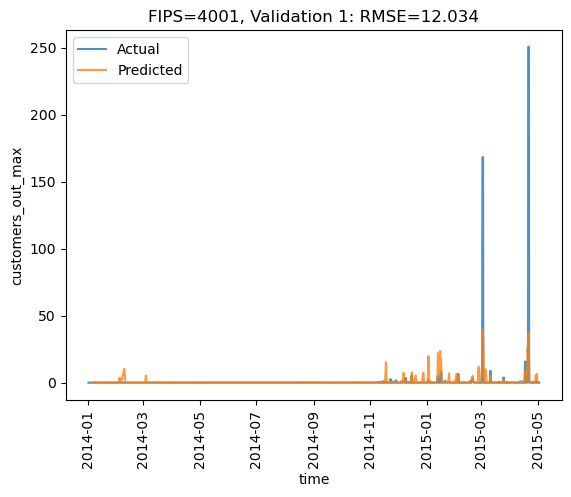

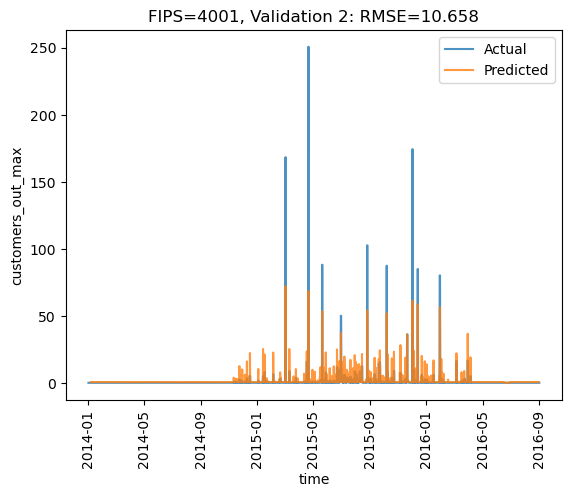

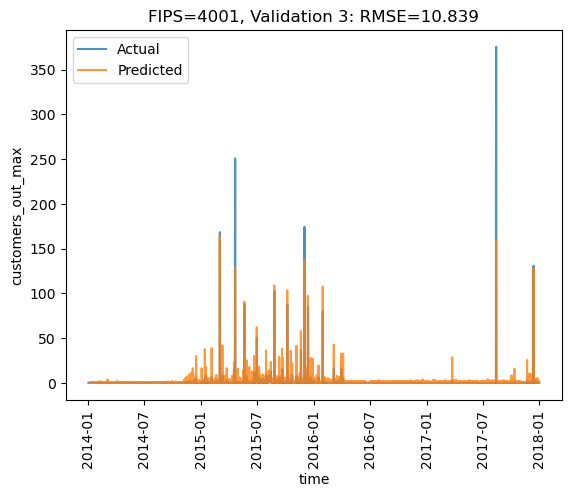

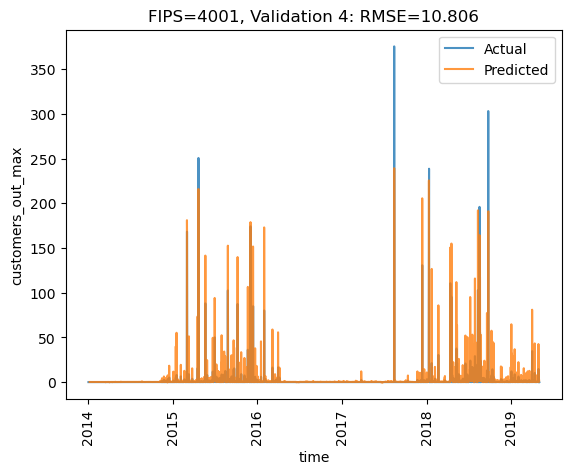

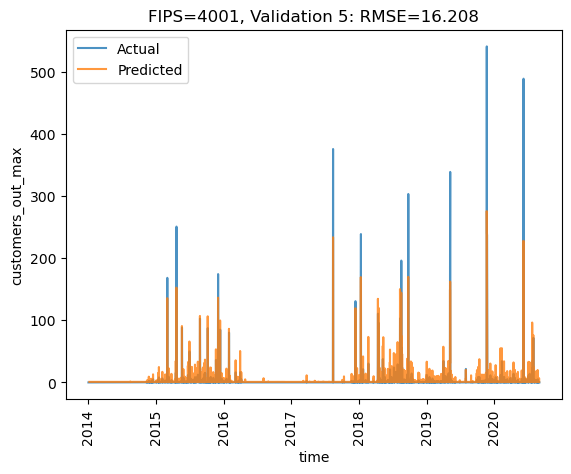

In [17]:
for i , x in enumerate(train_results[fips_test]):
    fig, ax = plt.subplots()
    l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
    l1 = ax.plot(x['Predicted'],label = 'Predicted',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)

    common_indices = x['Actual'].dropna().index.intersection(x['Predicted'].dropna().index)
    rmse = MSEsktime(square_root=True)

    ax.set_title(f'FIPS={int(fips_test)}, Validation {i+1}: RMSE={round(rmse(x['Actual'].loc[common_indices],x['Predicted'].loc[common_indices]),3)}')
    plt.xticks(rotation=90)
    plt.show()

In [18]:
metrics

{4001: [{'loss': 152.57369995117188,
   'root_mean_squared_error': 12.352072715759277},
  {'loss': 296.0064697265625, 'root_mean_squared_error': 17.204837799072266},
  {'loss': 369.95147705078125, 'root_mean_squared_error': 19.23412322998047},
  {'loss': 1101.2620849609375, 'root_mean_squared_error': 33.18526840209961},
  {'loss': 7224.3671875, 'root_mean_squared_error': 84.99627685546875}],
 4011: [{'loss': 4.103214296113933e-12,
   'root_mean_squared_error': 2.0256393327144906e-06},
  {'loss': 0.0, 'root_mean_squared_error': 0.0},
  {'loss': 0.0, 'root_mean_squared_error': 0.0},
  {'loss': 0.0, 'root_mean_squared_error': 0.0},
  {'loss': 0.0, 'root_mean_squared_error': 0.0}],
 4013: [{'loss': 1345655.875, 'root_mean_squared_error': 1160.0240478515625},
  {'loss': 1210887.75, 'root_mean_squared_error': 1100.4034423828125},
  {'loss': 9570720.0, 'root_mean_squared_error': 3093.657958984375},
  {'loss': 1192693.625, 'root_mean_squared_error': 1092.1051025390625},
  {'loss': 5681777.0, '

## Predictions on test data

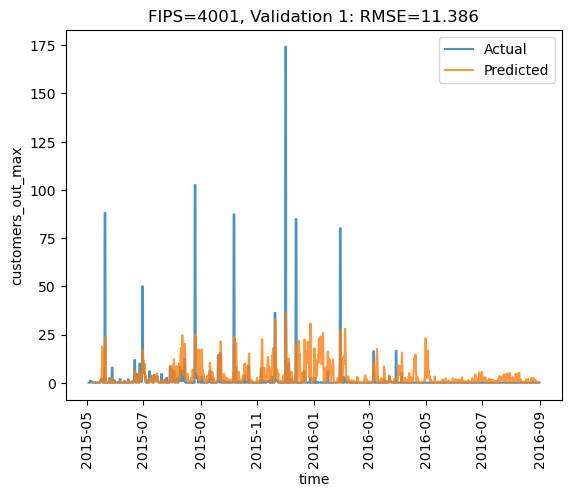

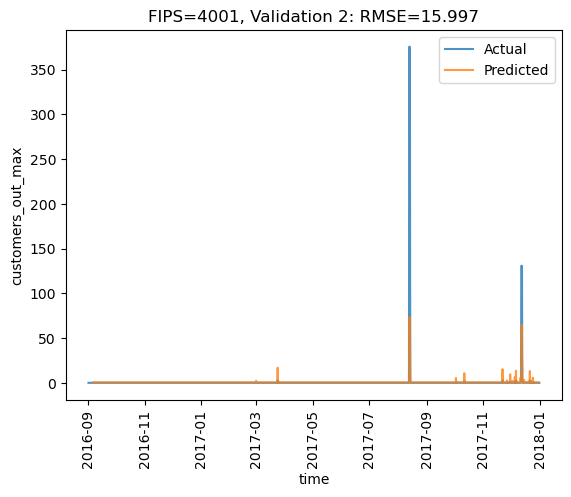

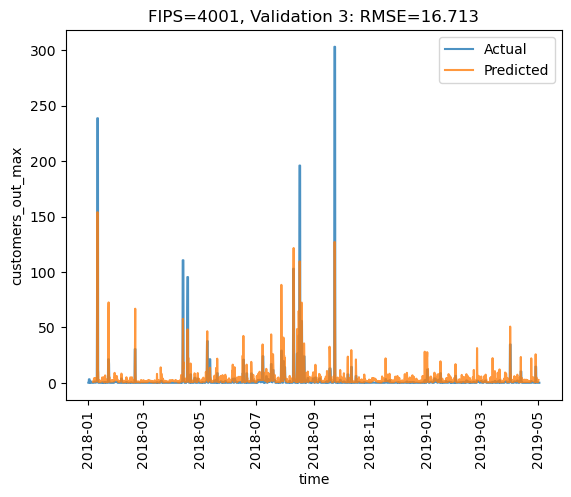

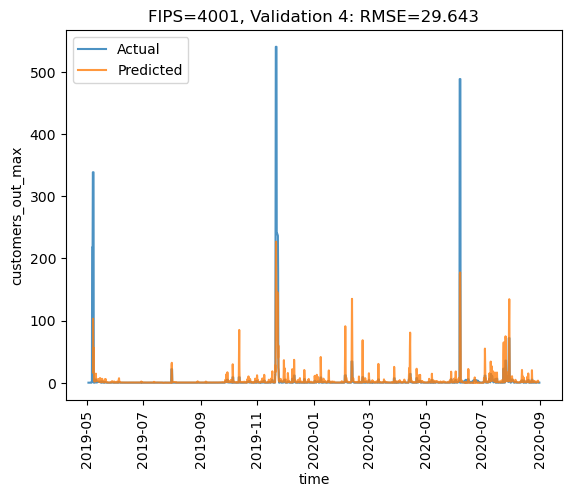

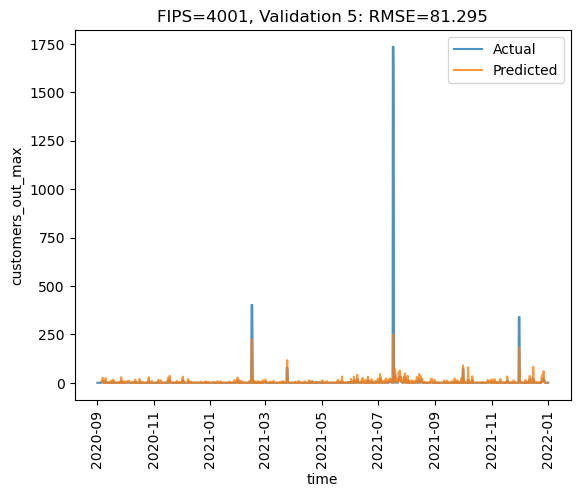

In [19]:
for i , x in enumerate(test_results[fips_test]):
    fig, ax = plt.subplots()
    l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
    l1 = ax.plot(x['Predicted'],label = 'Predicted',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)

    common_indices = x['Actual'].dropna().index.intersection(x['Predicted'].dropna().index)
    rmse = MSEsktime(square_root=True)

    ax.set_title(f'FIPS={int(fips_test)}, Validation {i+1}: RMSE={round(rmse(x['Actual'].loc[common_indices],x['Predicted'].loc[common_indices]),3)}')
    plt.xticks(rotation=90)
    plt.show()

## Forecast on test data

Below we show the 24hr forecast of `customers_out_max` compared to the real data. First we show an interactive plot and then we show the plots for all validations.

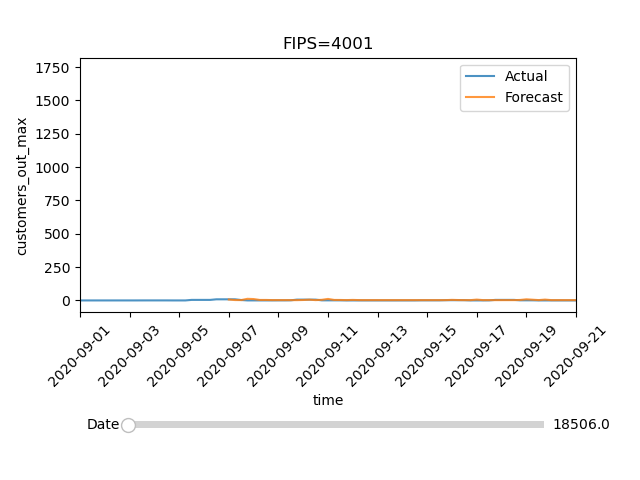

In [20]:
%matplotlib widget

import matplotlib
#import ipywidgets as wd

fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.35)
ax.set_xlabel('time')
ax.set_ylabel(target)
ax.set_title(f'FIPS={int(fips_test)}')
plt.xticks(rotation=45)

x = test_results[fips_test][-1]

l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
l1 = ax.plot(x['Forecast'],label = 'Forecast',alpha = 0.8)
ax.legend()

x_min_index = 0
x_max_index = 20*FORECAST_SIZE

x_min = x.index[x_min_index]
x_max = x.index[x_max_index]

x_dt = x_max - x_min

y_min = plt.axis()[2]
y_max = plt.axis()[3]

plt.axis([x_min, x_max, y_min, y_max])

axpos = plt.axes([0.2, 0.1, 0.65, 0.03])

slider_max = len(x) - x_max_index - 1

spos = Slider(axpos,'Date',matplotlib.dates.date2num(x_min),matplotlib.dates.date2num(x.index[slider_max]))

# play = wd.Play(value = matplotlib.dates.date2num(x_min),
#                min = matplotlib.dates.date2num(x_min),
#                max = matplotlib.dates.date2num(x[slider_max]),
#                step = 1,
#                interval = 500,
#                description = "Press play",
#                disabled = False)

# spos2 = wd.IntSlider(value = matplotlib.dates.date2num(x_min),
#                min = matplotlib.dates.date2num(x_min),
#                max = matplotlib.dates.date2num(x[slider_max]))

# wd.jslink((play,'value'),(spos2,'value'))

# def slider_update(change):
#     pos = change.new
#     x_min_time = matplotlib.dates.num2date(pos)
#     x_max_time = matplotlib.dates.num2date(pos+2)
#     #ax.set_title(f'x_min_time: {type(x_min_time)}')
#     ax.axis([x_min_time,x_max_time,y_min,y_max])

def update(val):
    pos = spos.val
    x_min_time = matplotlib.dates.num2date(pos)
    x_max_time = matplotlib.dates.num2date(pos+2)
    #ax.set_title(f'x_min_time: {type(x_min_time)}')
    ax.axis([x_min_time,x_max_time,y_min,y_max])

spos.on_changed(update)

plt.show()

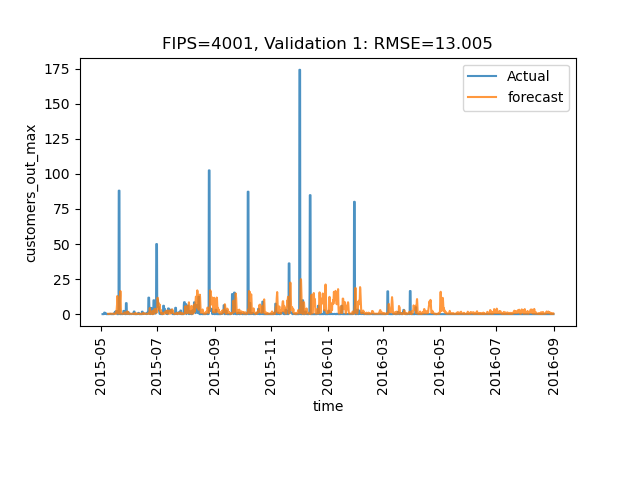

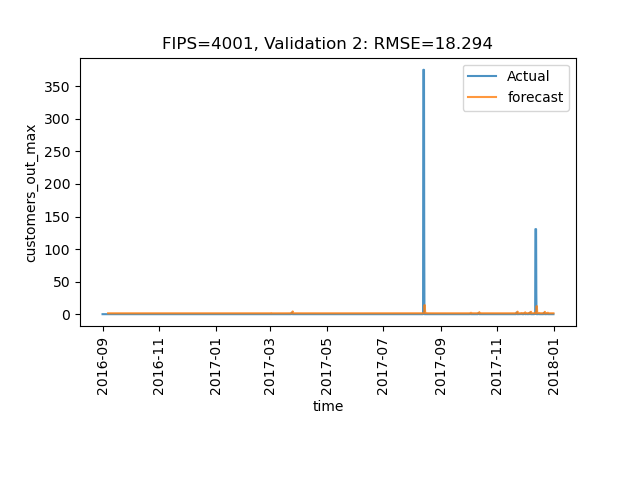

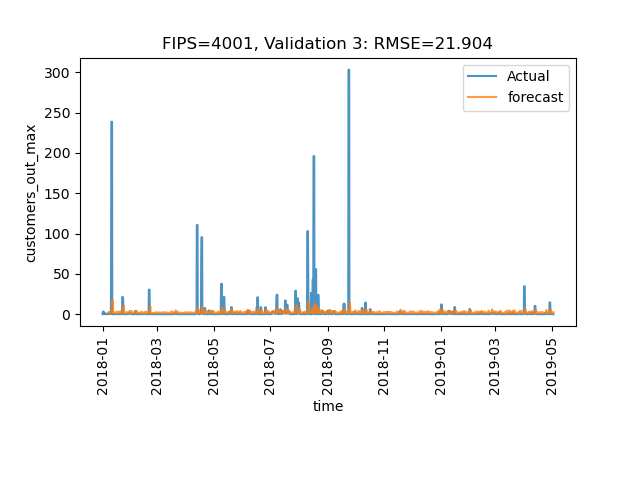

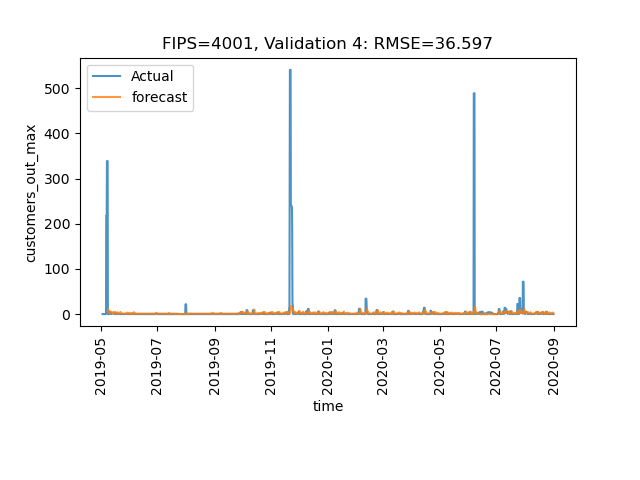

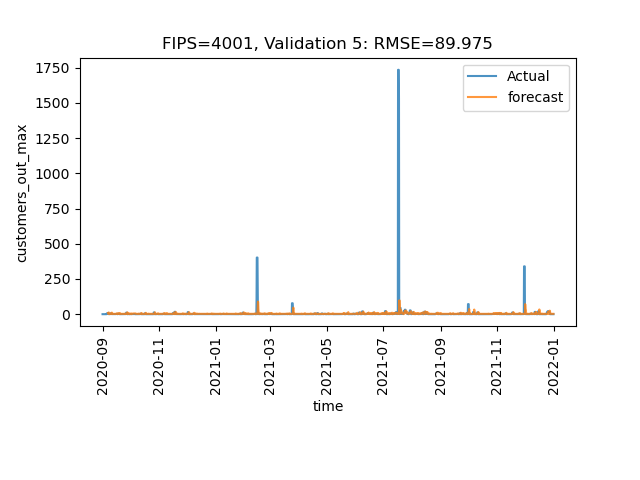

In [ ]:
%matplotlib widget

for i , x in enumerate(test_results[fips_test]):
    fig, ax = plt.subplots()
    fig.subplots_adjust(bottom=0.32)
    l2 = ax.plot(x['Actual'], label = 'Actual', alpha = 0.8)
    l1 = ax.plot(x['Forecast'],label = 'forecast',alpha = 0.8)
    ax.legend()
    ax.set_xlabel('time')
    ax.set_ylabel(target)

    common_indices = x['Actual'].dropna().index.intersection(x['Forecast'].dropna().index)
    rmse = MSEsktime(square_root=True)

    ax.set_title(f'FIPS={int(fips_test)}, Validation {i+1}: RMSE={round(rmse(x['Actual'].loc[common_indices],x['Forecast'].loc[common_indices]),3)}')

    plt.xticks(rotation=90)

    plt.show()

## RMSEs for all counties

In [75]:
rmses_state = {}

for fips in fips_list:
    x = test_results[fips][-1]
    common_indices = x['Actual'].dropna().index.intersection(x['Predicted'].dropna().index)
    rmse = MSEsktime(square_root=True)
    
    rmses_state[str(fips)] = round(rmse(x['Actual'].loc[common_indices],x['Predicted'].loc[common_indices]),3)

df_rmses = pd.DataFrame.from_dict(rmses_state,orient='index',columns=['RMSE'])

population_by_fips = df_state.groupby('fips_code')['POPULATION'].mean().reset_index()
population_by_fips.set_index('fips_code',inplace=True)
population_by_fips.index = population_by_fips.index.astype(str)

df_rmses['Population'] = population_by_fips['POPULATION']
df_rmses['Relative RMSE'] = df_rmses['RMSE']/population_by_fips['POPULATION']


c:\Users\cacereje\AppData\Local\miniconda3\envs\erdos_spring_2025\Lib\site-packages\sktime\performance_metrics\forecasting\_classes.py:673: UserWarning: y_pred and y_true do not have the same column index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(


In [76]:
df_rmses

,RMSE,Population,Relative RMSE
45001,95.745,25417.0,0.003767
45059,105.789,66537.0,0.001590
45061,27.516,19220.0,0.001432
45063,190.706,262391.0,0.000727
45009,10.962,15987.0,0.000686
45065,56.885,10233.0,0.005559
45067,59.602,33062.0,0.001803
45069,42.578,28933.0,0.001472
45007,792.480,187126.0,0.004235
45071,42.318,37508.0,0.001128


In [77]:
import geopandas as gpd
loc = '../../data/NWS_US_Counties_Shapefiles/c_05mr24.shp'
counties = gpd.read_file(loc)

counties = counties[counties['STATE'] == state]
counties.set_index('FIPS', inplace=True)


Below we have the RMSE for each county in the state.

In [78]:
counties = counties.join(df_rmses, how='left')
#counties = pd.concat([counties,df_rmses],axis=1)
counties

,STATE,CWA,COUNTYNAME,TIME_ZONE,FE_AREA,LON,LAT,geometry,RMSE,Population,Relative RMSE
FIPS,,,,,,,,,,,
45001,SC,GSP,Abbeville,E,up,-82.4587,34.2226,"POLYGON ((-82.26109 34.42061, -82.258 34.41941...",95.745,25417.0,0.003767
45005,SC,CHS,Allendale,E,se,-81.3581,32.9881,"POLYGON ((-81.5419 33.15821, -81.53 33.15521, ...",25.800,10419.0,0.002476
45007,SC,GSP,Anderson,E,up,-82.6379,34.5191,"POLYGON ((-82.47569 34.80501, -82.4762 34.8025...",792.480,187126.0,0.004235
45009,SC,CAE,Bamberg,E,cc,-81.0542,33.2147,"POLYGON ((-81.2194 33.43891, -81.2151 33.43851...",10.962,15987.0,0.000686
45021,SC,GSP,Cherokee,E,up,-81.6204,35.0482,"POLYGON ((-81.4592 35.16861, -81.45129 35.1681...",163.684,55342.0,0.002958
45023,SC,GSP,Chester,E,up,-81.1595,34.6921,"POLYGON ((-81.1199 34.82031, -81.0795 34.82081...",58.065,33140.0,0.001752
45025,SC,CAE,Chesterfield,E,cc,-80.1586,34.6398,"POLYGON ((-80.504 34.81731, -80.4918 34.81681,...",97.564,46734.0,0.002088
45031,SC,ILM,Darlington,E,ne,-79.9577,34.3323,"POLYGON ((-79.81229 34.49321, -79.8111 34.4887...",101.673,68681.0,0.001480
45037,SC,CAE,Edgefield,E,cc,-81.9666,33.7723,"POLYGON ((-81.88609 33.94501, -81.8817 33.9305...",27.288,26985.0,0.001011


Here's a summary of the RMSE's:

In [69]:
counties['Relative RMSE'].describe()

count    50.000000
mean      0.002633
std       0.002879
min       0.000542
25%       0.001149
50%       0.001492
75%       0.002951
max       0.015994
Name: Relative RMSE, dtype: float64

In [79]:
import geopandas as gpd
from matplotlib.colors import ListedColormap, Normalize

def plot_rmse_on_map_state(data,feature,state=state):
    
    loc = '../../data/NWS_US_Counties_Shapefiles/c_05mr24.shp'
    counties = gpd.read_file(loc)

    counties = counties[counties['STATE'] == state]
    counties.set_index('FIPS', inplace=True)
    
    counties = counties.join(data,how='left')

    # Create a custom colormap
    viridis_cmap = plt.cm.viridis  # Base colormap
    colors = viridis_cmap(np.linspace(0, 1, 256))  # Extract colors from viridis
    colors[0] = np.array([1, 1, 1, 1])  # Set the first color (for zero values) to white
    custom_cmap = ListedColormap(colors)
    
    # Plot the map
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    county_plot = counties.plot(column=feature,  # Data to visualize
                                cmap=custom_cmap,  # Colormap
                                linewidth=0.8,
                                ax=ax,
                                edgecolor='black',
                                legend=False,  # Disable automatic colorbar
                                norm=Normalize(vmin=0, vmax=counties[feature].max())  # Normalize scale
                               )
    
    # Add colorbar and set its title
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=Normalize(vmin=0, vmax=counties[feature].max()))
    sm._A = []  # Dummy array for the ScalarMappable
    cbar = fig.colorbar(sm, ax=ax)
    # cbar.set_label('Number of Customers Out', fontsize=12, labelpad=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.set_xlabel('RMSE', fontsize=14)
    
    # Remove the vertical label
    cbar.ax.set_ylabel('')
    
    # Customize the plot
    title = f"{feature} for each county in {state}"
    ax.set_title(title, fontsize=14)
    ax.axis('off')  # Turn off the axis
    plt.show()

    return


and here a map to visualize where the RMSE is the highest. This should be compared to the map that shows the outages for the time period.

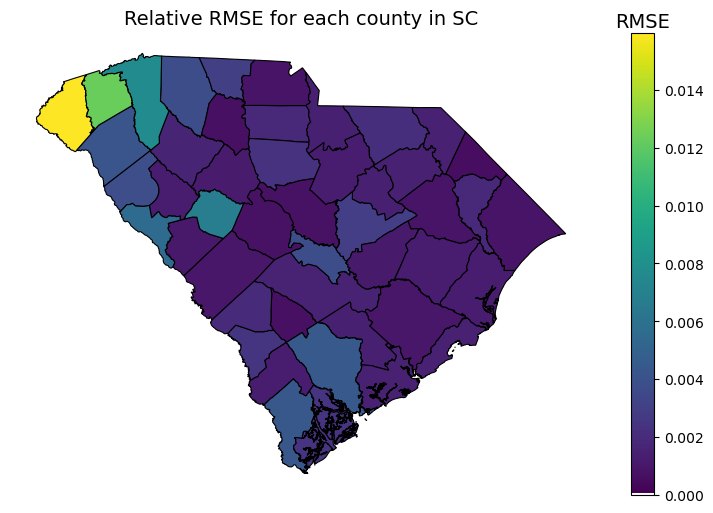

In [80]:
plot_rmse_on_map_state(df_rmses,feature='Relative RMSE',state=state)

Below we save our RMSE's for each county in this state together with their geometry.

In [82]:
counties.to_csv(f'results/RMSE_LSTM_{state}')